## Predykcja szeregów czasowych z użyciem modelu SARIMA na bazie danych sieci sklepów Walmart

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from matplotlib import dates
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Przedstawienie zbioru danych

In [116]:
# Konwersja danych csv do dataframe pandas
calendar=pd.read_csv('dataset/calendar.csv', parse_dates=["date"])
sales=pd.read_csv('dataset/sales_train_evaluation.csv')
prices=pd.read_csv('dataset/sell_prices.csv')
calendar['date']=pd.to_datetime(calendar['date'])
sample_submission=pd.read_csv('dataset/sample_submission.csv')

# Redukcja zużycia pamięci

In [117]:
# Funkcja do redukcji zużycia pamięci przez dobór najmniejszych możliwych typów danych
def reduce_mem_usage(df, verbose=False):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df


In [118]:
# Redukcja pamięci dla wczytanych ramek danych
calendar = reduce_mem_usage(calendar)
sales = reduce_mem_usage(sales)
prices = reduce_mem_usage(prices)


In [119]:
# pierwsze pięć wierszy dataframu calendar:
print(calendar.shape)
calendar.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [120]:
# Informacje na temat dataframu calendar
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[us]
 1   wm_yr_wk      1969 non-null   int16         
 2   weekday       1969 non-null   str           
 3   wday          1969 non-null   int8          
 4   month         1969 non-null   int8          
 5   year          1969 non-null   int16         
 6   d             1969 non-null   str           
 7   event_name_1  162 non-null    str           
 8   event_type_1  162 non-null    str           
 9   event_name_2  5 non-null      str           
 10  event_type_2  5 non-null      str           
 11  snap_CA       1969 non-null   int8          
 12  snap_TX       1969 non-null   int8          
 13  snap_WI       1969 non-null   int8          
dtypes: datetime64[us](1), int16(2), int8(5), str(6)
memory usage: 125.1 KB


In [121]:
# Informacje na temat dataframu sales
print(sales.shape)
sales.head(5)

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [122]:
# Informacje na temat dataframu prices
print(prices.shape)
prices.head()

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.578125
1,CA_1,HOBBIES_1_001,11326,9.578125
2,CA_1,HOBBIES_1_001,11327,8.257812
3,CA_1,HOBBIES_1_001,11328,8.257812
4,CA_1,HOBBIES_1_001,11329,8.257812


# Normalizacja danych
Tabele łączone są w jedną dla prostoty przeprowadzania analizy

In [123]:
# kolumny id produktu (nie-dniowe) vs kolumny dni (d_1, d_2, ...)
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales.columns if c.startswith("d_")]
calendar=calendar.fillna(-1)

In [124]:
sales_long = sales.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales"
)

In [125]:
print(sales_long.shape)
sales_long.head()

(59181090, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [126]:
# dołączanie dataframe calendar po kolumnie d
sales_long = sales_long.merge(calendar, on="d", how="left")

In [127]:
# dołączanie dataframe prices po kolumnach store_id, item_id oraz wm_yr_wk
sales_long = sales_long.merge(
    prices, on=["store_id", "item_id", "wm_yr_wk"], how="left"
)

In [128]:
# Konwersja kolumn identyfikatorowych/kategorycznych na typ 'category'
cat_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id",
            "d", "wm_yr_wk", "weekday", "event_name_1", "event_type_1",
            "event_name_2", "event_type_2"]
for c in cat_cols:
    if c in sales_long.columns:
        sales_long[c] = sales_long[c].astype("category")

sales_long = reduce_mem_usage(sales_long)


In [129]:
sales_long.tail()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,2.980469
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,2.480469
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,3.980469
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,1.280273
59181089,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,1.000000


<Axes: xlabel='date'>

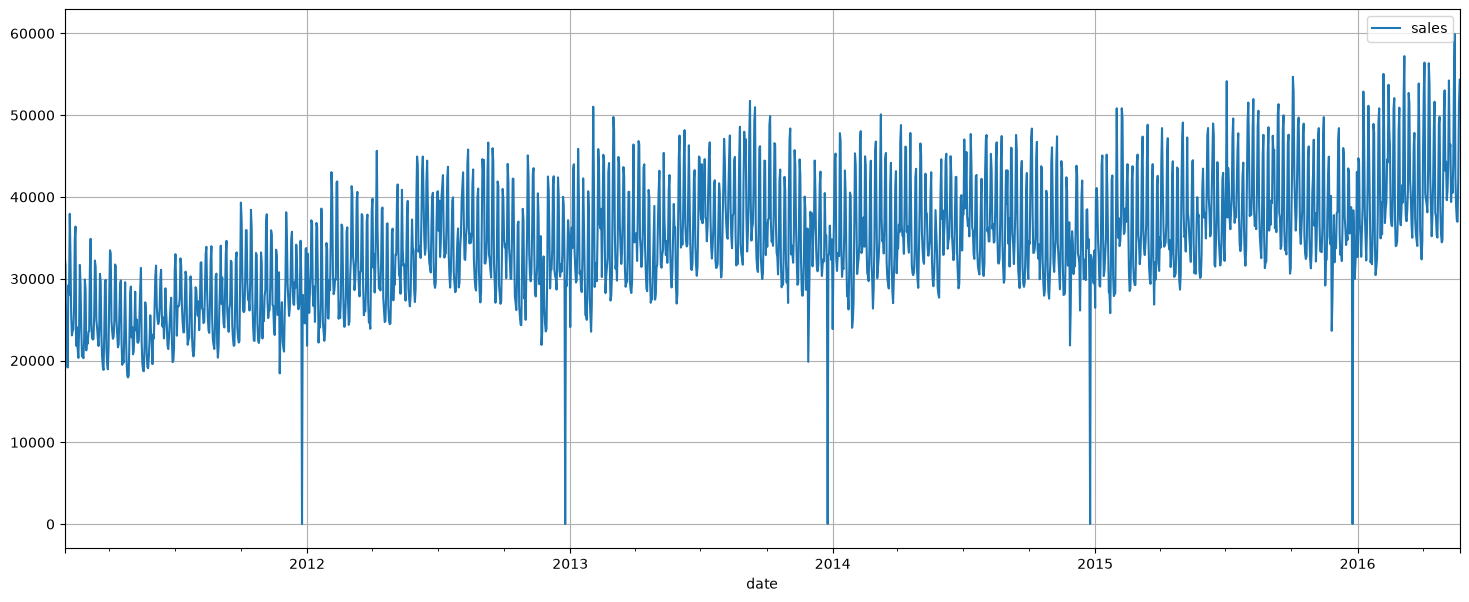

In [130]:
sales_long[['date','sales']].groupby('date').agg({'sales':'sum'}).plot(figsize=(18,7),grid=True)

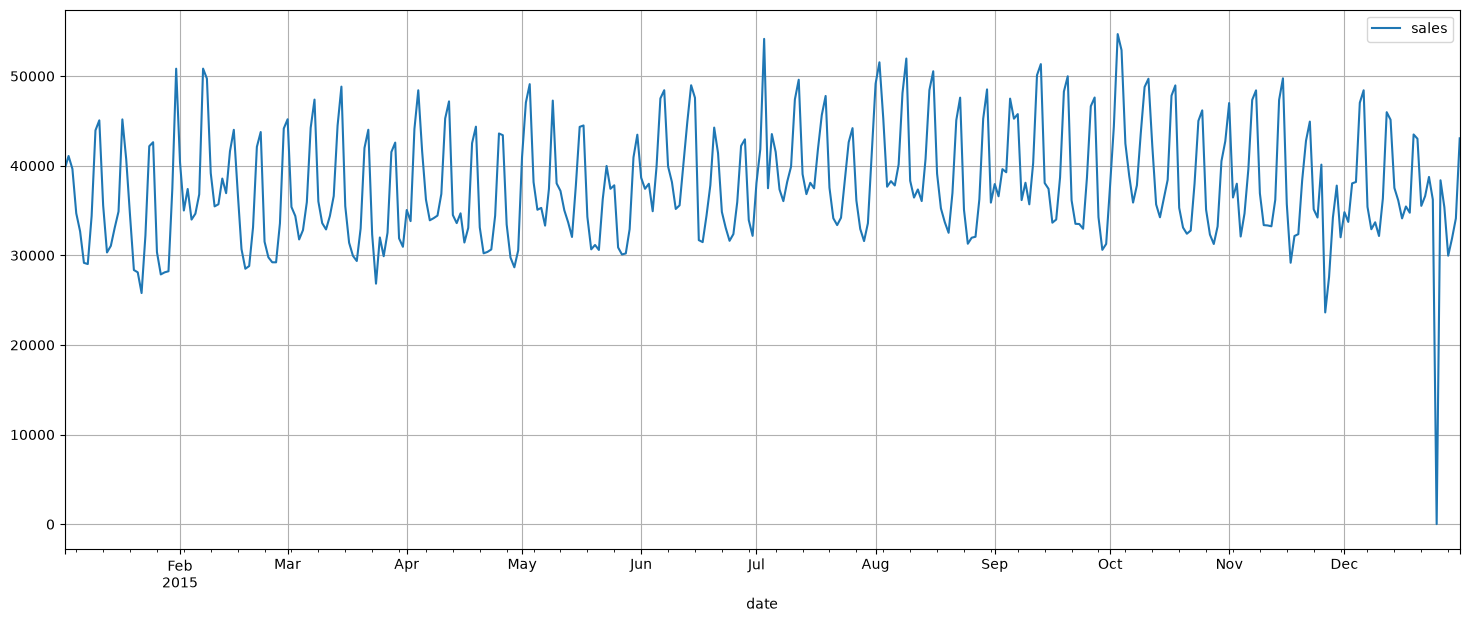

In [131]:
sales_long.loc[(sales_long.date>'2015-01-01')&(sales_long.date<'2016-01-01')][['date','sales']].groupby('date').agg({'sales':'sum'}).plot(figsize=(18,7),grid=True);

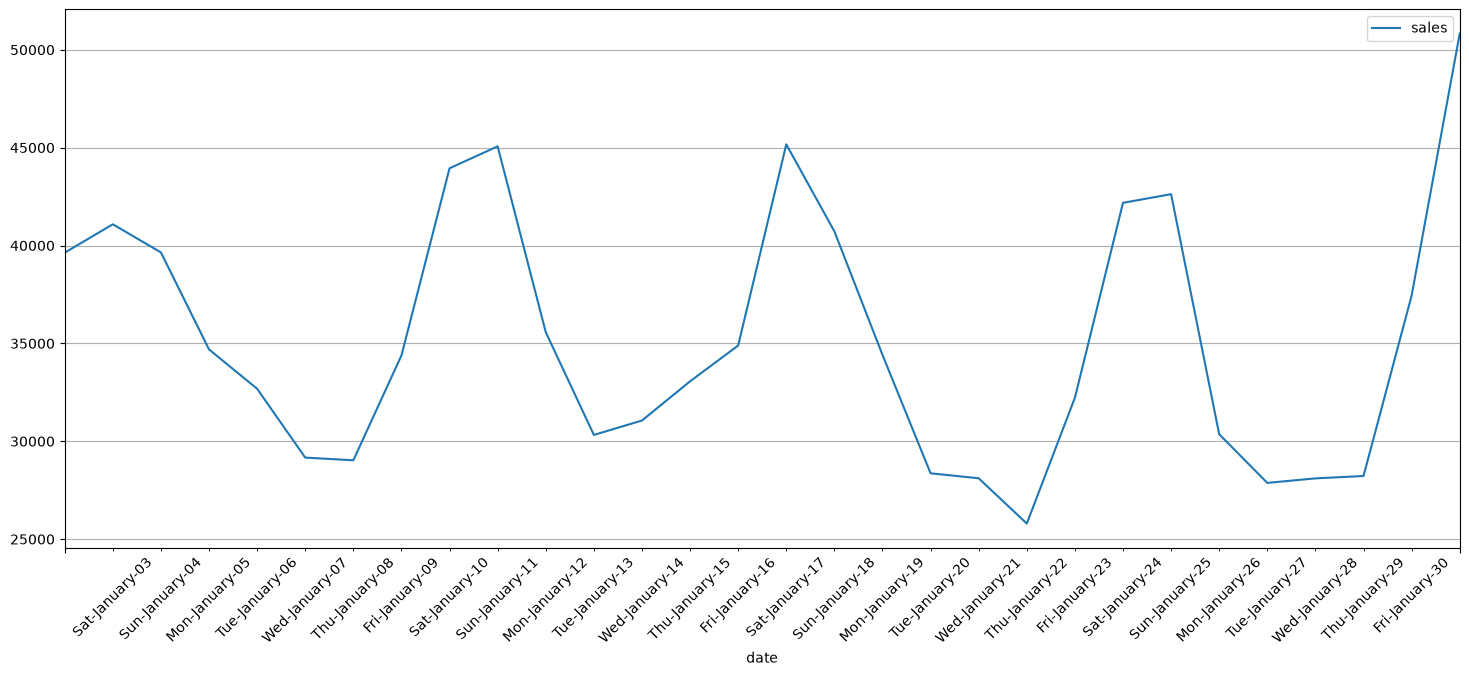

In [132]:
monthly_plot=sales_long.loc[(sales_long.date>'2015-01-01')&(sales_long.date<'2015-02-01')][['date','sales']].groupby('date').agg({'sales':'sum'}).plot(figsize=(18,7),grid=True);
monthly_plot.xaxis.set_minor_locator(dates.DayLocator())
monthly_plot.xaxis.set_minor_formatter(dates.DateFormatter("%a-%B-%d"))
monthly_plot.tick_params(which='minor', rotation=45)

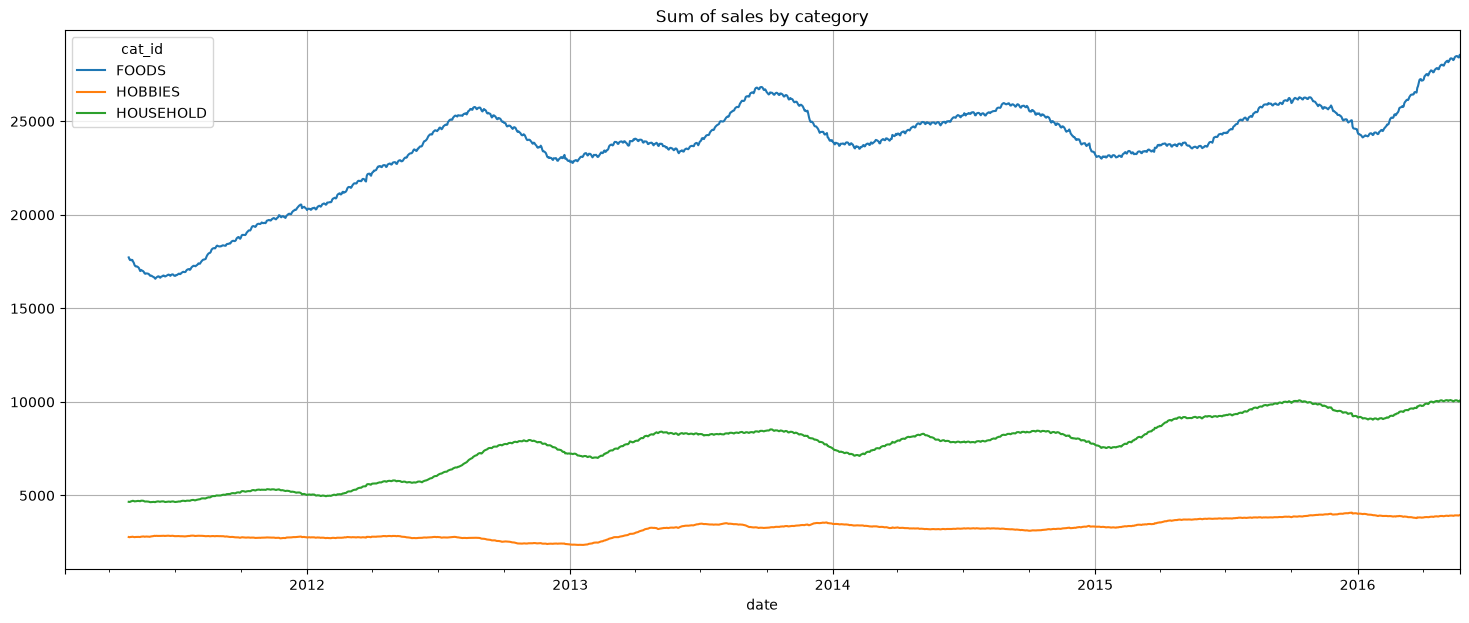

In [133]:
category_wise=sales_long[['date','cat_id','sales']].groupby(['date','cat_id']).agg({'sales':'sum'})
category_wise.reset_index(inplace=True)
category_wise.pivot(index="date", columns="cat_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales by category');

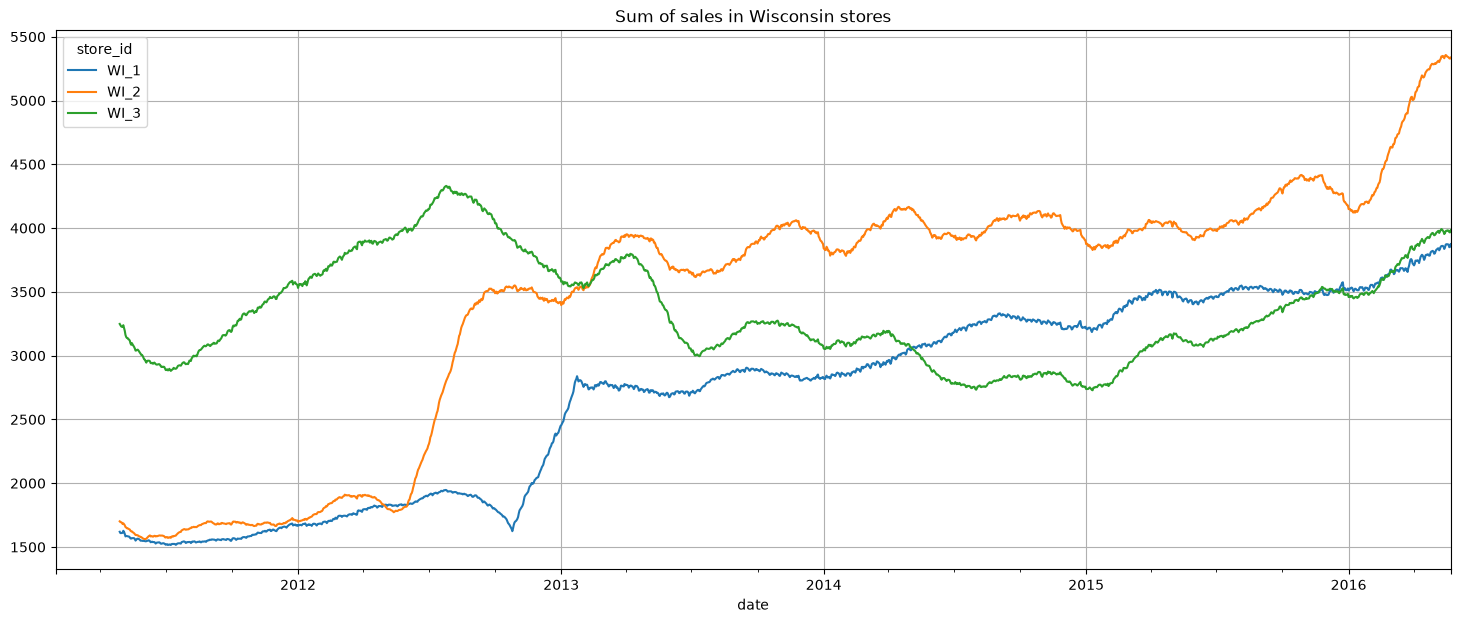

In [134]:
state_wise_wisconsin=sales_long.loc[sales_long.state_id=='WI'][['date','store_id','sales']].groupby(['date','store_id']).agg({'sales':'sum'})
state_wise_wisconsin.reset_index(inplace=True)
state_wise_wisconsin.pivot(index="date", columns="store_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales in Wisconsin stores');

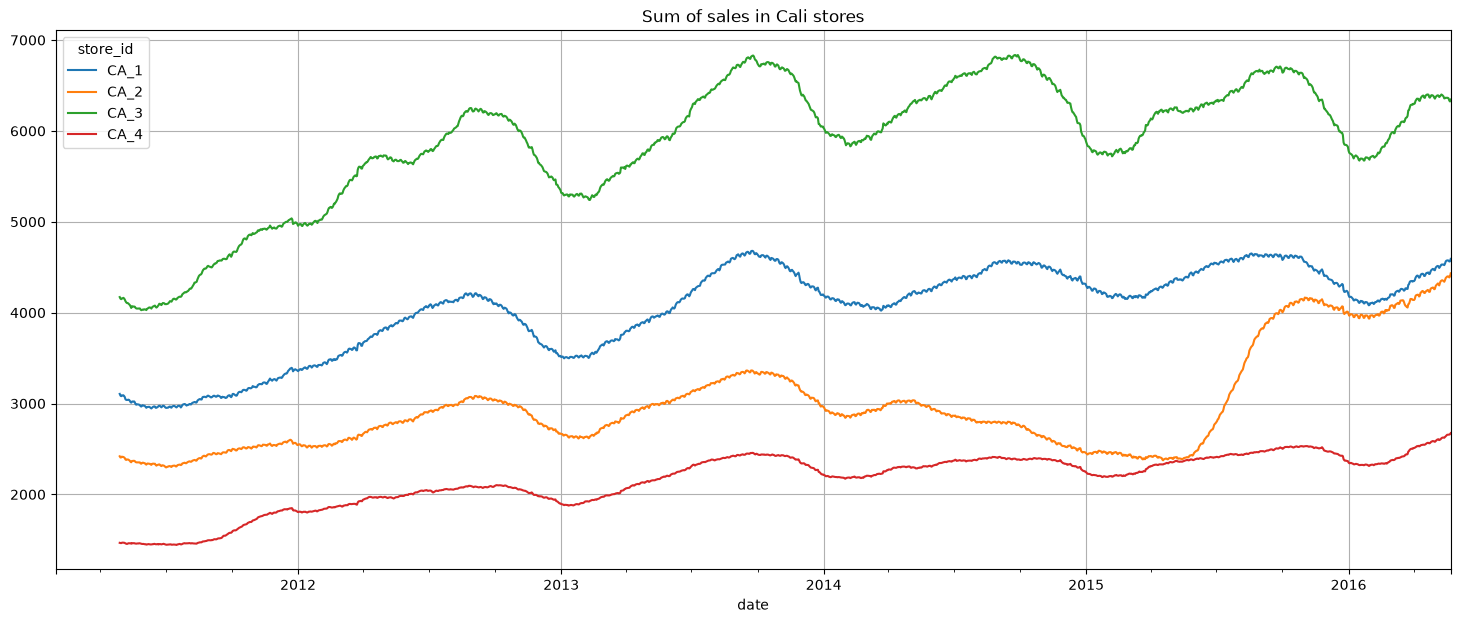

In [135]:
state_wise_wisconsin=sales_long.loc[sales_long.state_id=='CA'][['date','store_id','sales']].groupby(['date','store_id']).agg({'sales':'sum'})
state_wise_wisconsin.reset_index(inplace=True)
state_wise_wisconsin.pivot(index="date", columns="store_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales in Cali stores');

<Axes: title={'center': 'Sum of sales in Texas stores'}, xlabel='date'>

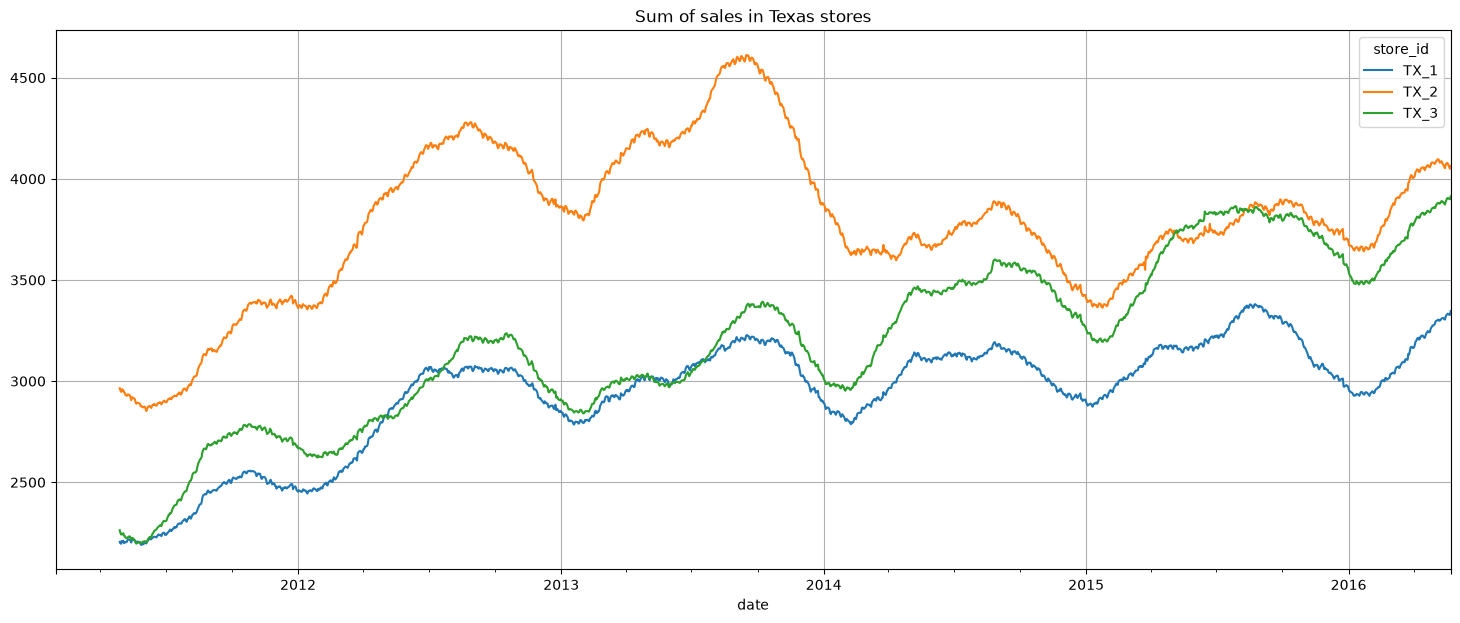

In [136]:
state_wise_wisconsin=sales_long.loc[sales_long.state_id=='TX'][['date','store_id','sales']].groupby(['date','store_id']).agg({'sales':'sum'})
state_wise_wisconsin.reset_index(inplace=True)
state_wise_wisconsin.pivot(index="date", columns="store_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales in Texas stores')

In [137]:
# Stworzenie kolumny 'snap' dla prostoty
sales_long['snap'] = np.where(sales_long['state_id']=='CA', sales_long['snap_CA'],
             np.where(sales_long['state_id']=='TX', sales_long['snap_TX'],
             np.where(sales_long['state_id']=='WI', sales_long['snap_WI'], 0)))

In [138]:
# Podział na kategorie 
foods_CA_daily = (
    sales_long
    .loc[(sales_long["state_id"] == "CA") & (sales_long["cat_id"] == "FOODS")]
    .assign(date=lambda d: pd.to_datetime(d["date"]))
    .groupby("date")
    .agg(
        sales=("sales", "sum"),
        snap=("snap", "first"),
    )
    .asfreq("D")
)

# Kompletność osi czasu i identyfikacja zer strukturalnych

Mniejsze wartości przypadające na 25 grudnia wynikają z zamknięcia sklepów, a nie z braku
popytu. Zgodnie z przyjętym w pracy rozwiązaniem pozostawia się je bez korekty;
poniższa komórka służy wyłącznie ich udokumentowaniu.

In [139]:
# Kontrola kompletności osi czasu po asfreq("D")
n_braki = foods_CA_daily["sales"].isna().sum()
print(f"Liczba braków danych po uzupełnieniu osi czasu: {n_braki}")

if n_braki:
    foods_CA_daily = foods_CA_daily.fillna(0)
    print("  -> braki uzupełniono wartością zerową")
else:
    print("  -> oś czasu jest kompletna, uzupełnianie zbędne")

# Identyfikacja obserwacji nietypowych (świąteczne zamknięcia sklepów)
swieta = [d for d in foods_CA_daily.index if (d.month, d.day) == (12, 25)]

print(f"Obserwacje świąteczne: {len(swieta)}")
for d in swieta:
    print(f"   {d.date()}: {foods_CA_daily.loc[d, 'sales']:>10,.0f} szt.")

srednia = foods_CA_daily["sales"].mean()
print(f"\nŚrednia sprzedaż dzienna: {srednia:,.0f} szt.")
print(f"Udział sprzedaży świątecznej w średniej: "
      f"{foods_CA_daily.loc[swieta, 'sales'].mean() / srednia * 100:.2f}%")
print(f"Udział w zbiorze: {len(swieta) / len(foods_CA_daily) * 100:.2f}%")

Liczba braków danych po uzupełnieniu osi czasu: 0
  -> oś czasu jest kompletna, uzupełnianie zbędne
Obserwacje świąteczne: 5
   2011-12-25:          8 szt.
   2012-12-25:          6 szt.
   2013-12-25:          5 szt.
   2014-12-25:          6 szt.
   2015-12-25:          6 szt.

Średnia sprzedaż dzienna: 10,065 szt.
Udział sprzedaży świątecznej w średniej: 0.06%
Udział w zbiorze: 0.26%


# Analiza opisowa danych sprzedażowych

In [140]:
s = foods_CA_daily["sales"]

# [1] Statystyki opisowe — pełny szereg
stat = {
    "Liczba obserwacji": len(s),
    "Średnia": s.mean(),
    "Mediana": s.median(),
    "Odchylenie standardowe": s.std(),
    "Współczynnik zmienności [%]": s.std() / s.mean() * 100,
    "Minimum": s.min(),
    "Kwartyl dolny (Q1)": s.quantile(0.25),
    "Kwartyl górny (Q3)": s.quantile(0.75),
    "Maksimum": s.max(),
    "Rozstęp": s.max() - s.min(),
    "Skośność": s.skew(),
    "Kurtoza": s.kurtosis() + 3,
}
print("=" * 55)
print("[1] STATYSTYKI OPISOWE — pełny szereg")
print("=" * 55)
for k, v in stat.items():
    print(f"{k:32s}{v:>18,.2f}")

# [2] Te same miary po wyłączeniu zer strukturalnych
s_bez = s.drop(index=swieta)
print("\n" + "=" * 55)
print("[2] STATYSTYKI OPISOWE — z pominięciem zer strukturalnych")
print("=" * 55)
print(f"{'Liczba obserwacji':32s}{len(s_bez):>18,}")
print(f"{'Średnia':32s}{s_bez.mean():>18,.2f}")
print(f"{'Minimum':32s}{s_bez.min():>18,.2f}")
print(f"{'Skośność':32s}{s_bez.skew():>18,.2f}")
print(f"{'Kurtoza':32s}{s_bez.kurtosis() + 3:>18,.2f}")

[1] STATYSTYKI OPISOWE — pełny szereg
Liczba obserwacji                         1,941.00
Średnia                                  10,064.84
Mediana                                   9,813.00
Odchylenie standardowe                    2,140.35
Współczynnik zmienności [%]                  21.27
Minimum                                       5.00
Kwartyl dolny (Q1)                        8,680.00
Kwartyl górny (Q3)                       11,369.00
Maksimum                                 16,523.00
Rozstęp                                  16,518.00
Skośność                                      0.11
Kurtoza                                       3.80

[2] STATYSTYKI OPISOWE — z pominięciem zer strukturalnych
Liczba obserwacji                            1,936
Średnia                                  10,090.82
Minimum                                   5,080.00
Skośność                                      0.38
Kurtoza                                       2.83


In [141]:
# [3] Statystyki w podziale na lata
roczne = s.groupby(s.index.year).agg(
    liczba_dni="count", srednia="mean", mediana="median",
    odch_std="std", minimum="min", maksimum="max",
)
roczne["wsp_zmiennosci"] = roczne["odch_std"] / roczne["srednia"] * 100
print("[3] STATYSTYKI W PODZIALE NA LATA")
print(roczne.round(1).to_string())

pelne = roczne.loc[2012:2015, "srednia"]
print(f"\nZmiana średniej 2012 -> 2015: "
      f"{(pelne.loc[2015] / pelne.loc[2012] - 1) * 100:+.1f}%")

# [6] Wartości skrajne
print("\n[6] PIĘĆ NAJNIŻSZYCH OBSERWACJI")
print(s.nsmallest(5).to_string())
print("\n[6] PIĘĆ NAJWYŻSZYCH OBSERWACJI")
print(s.nlargest(5).to_string())

[3] STATYSTYKI W PODZIALE NA LATA
      liczba_dni  srednia  mediana  odch_std  minimum  maksimum  wsp_zmiennosci
date                                                                           
2011         337   8042.1   7771.0    1661.0        8     12465            20.7
2012         366  10227.5  10003.0    1938.3        6     16114            19.0
2013         365  10454.1  10119.0    1969.3        5     16523            18.8
2014         365  10517.4  10081.0    1893.7        6     15202            18.0
2015         365  10361.6   9938.0    1975.2        6     16328            19.1
2016         143  11509.3  10855.0    2060.8     8471     16338            17.9

Zmiana średniej 2012 -> 2015: +1.3%

[6] PIĘĆ NAJNIŻSZYCH OBSERWACJI
date
2013-12-25    5
2012-12-25    6
2014-12-25    6
2015-12-25    6
2011-12-25    8

[6] PIĘĆ NAJWYŻSZYCH OBSERWACJI
date
2013-09-08    16523
2016-03-26    16338
2015-10-04    16328
2016-03-06    16218
2016-05-15    16197


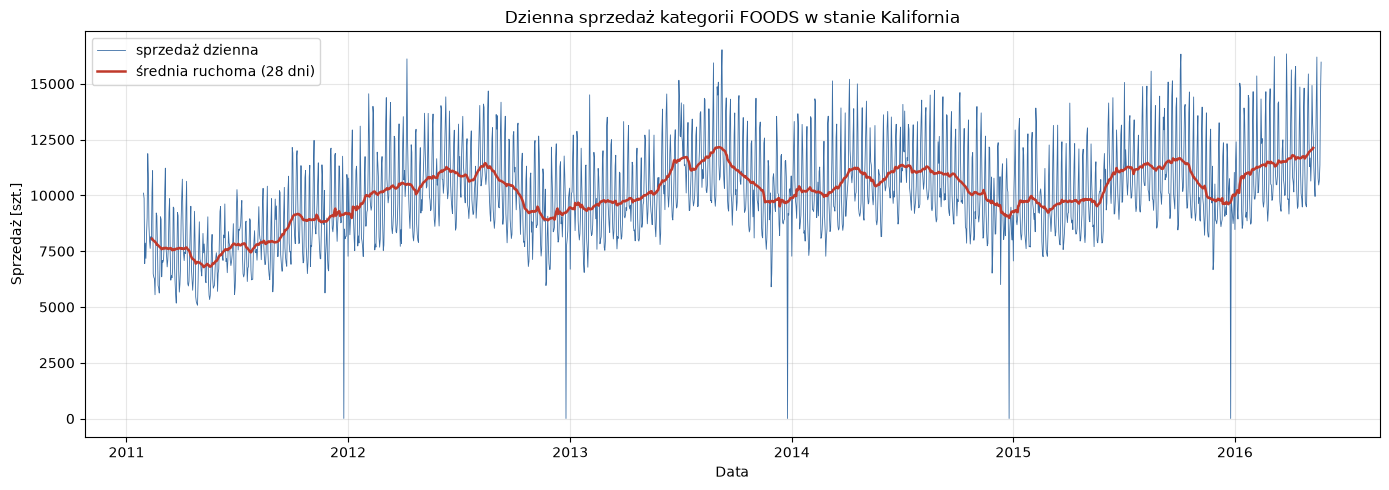

In [142]:
# [4] Rysunek: przebieg szeregu w całym okresie
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s.index, s.values, linewidth=0.6, color="#3b6ea5",
        label="sprzedaż dzienna")
ax.plot(s.index, s.rolling(28, center=True).mean(), linewidth=1.8,
        color="#c0392b", label="średnia ruchoma (28 dni)")
ax.set_xlabel("Data")
ax.set_ylabel("Sprzedaż [szt.]")
ax.set_title("Dzienna sprzedaż kategorii FOODS w stanie Kalifornia")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rys_2_3_szereg.png", dpi=200)
plt.show()

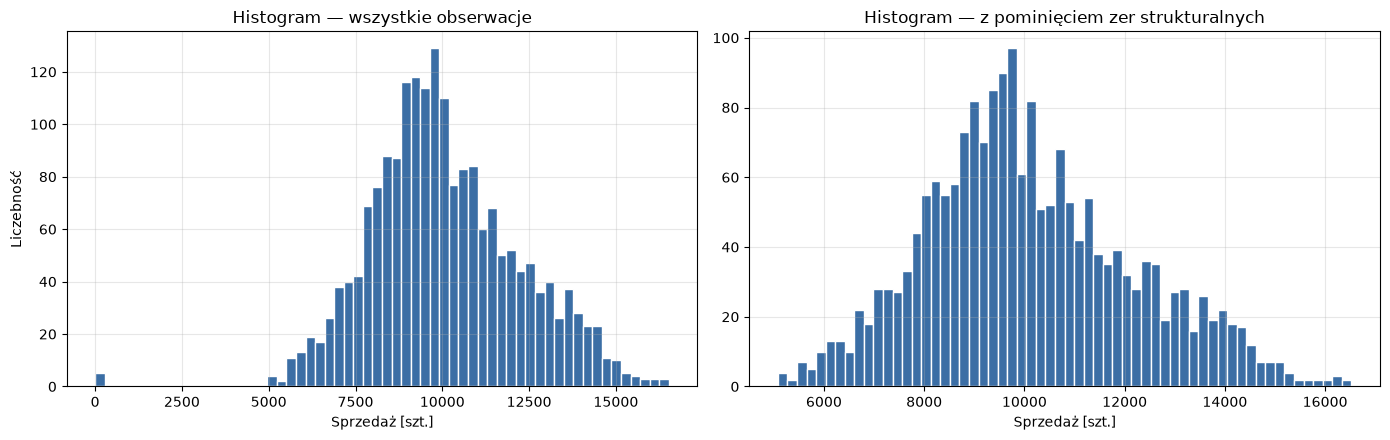

In [143]:
# [5] Rysunek: rozkład obserwacji
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(s, bins=60, color="#3b6ea5", edgecolor="white")
axes[0].set_title("Histogram — wszystkie obserwacje")
axes[0].set_xlabel("Sprzedaż [szt.]")
axes[0].set_ylabel("Liczebność")
axes[1].hist(s_bez, bins=60, color="#3b6ea5", edgecolor="white")
axes[1].set_title("Histogram — z pominięciem zer strukturalnych")
axes[1].set_xlabel("Sprzedaż [szt.]")
for a in axes:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rys_2_3_histogram.png", dpi=200)
plt.show()

In [144]:
s = foods_CA_daily["sales"]
snap = foods_CA_daily["snap"]

[1] DEKOMPOZYCJA STL (period = 7)
trend               wariancja:    1,648,119   udział:  34.3%
sezonowość          wariancja:    2,504,410   udział:  52.1%
reszta              wariancja:      652,732   udział:  13.6%

Amplituda składowej sezonowej: 7,099 szt.
Zakres składowej trendu:       6,118 - 12,554 szt.


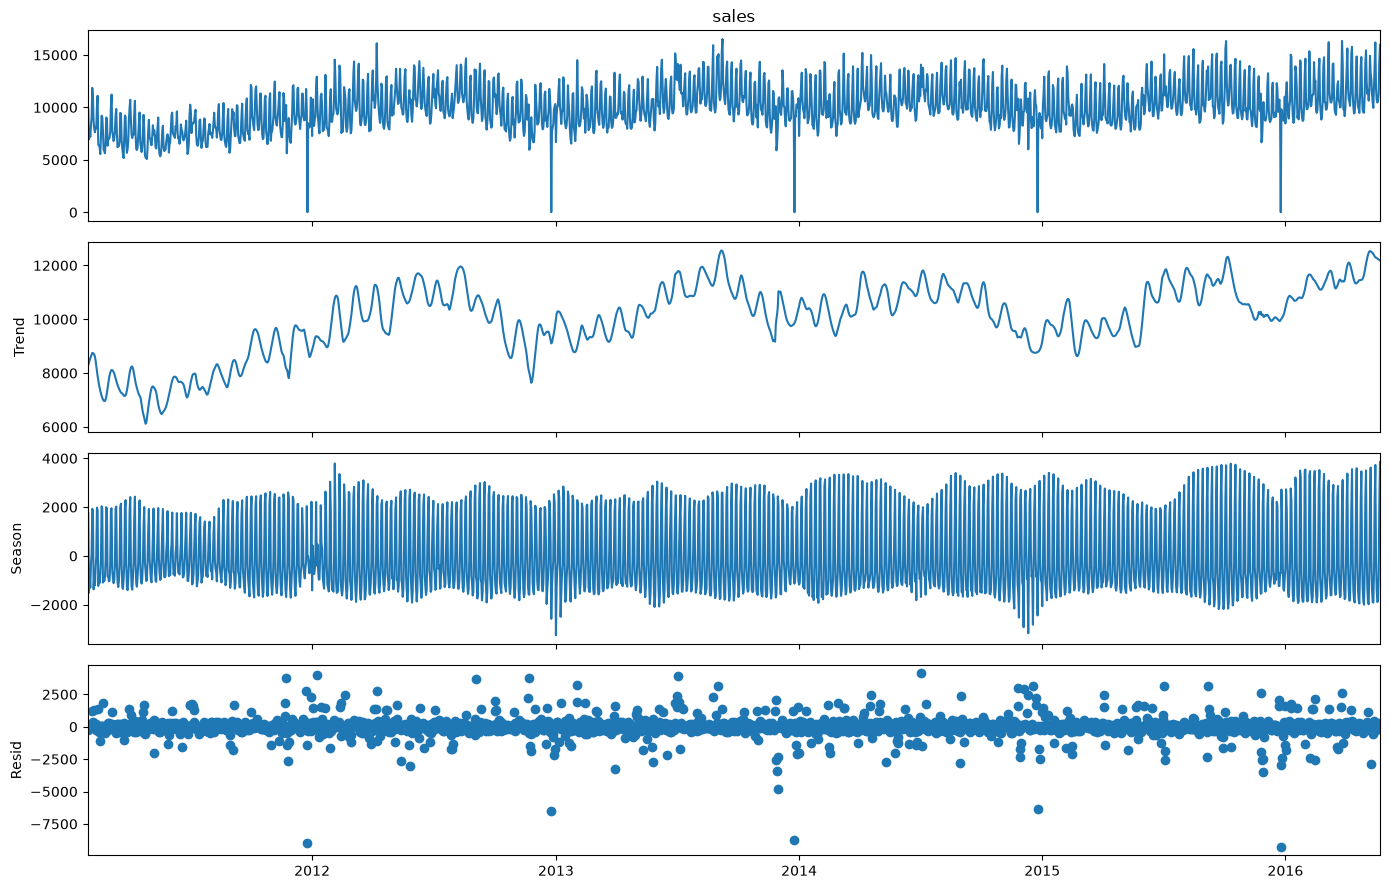

In [145]:
# Dekompozycja STL względem sezonowości tygodniowej
stl = STL(s, period=7, robust=True).fit()

udzial = {
    "trend": stl.trend.var(),
    "sezonowość": stl.seasonal.var(),
    "reszta": stl.resid.var(),
}
suma = sum(udzial.values())

print("=" * 58)
print("[1] DEKOMPOZYCJA STL (period = 7)")
print("=" * 58)
for k, v in udzial.items():
    print(f"{k:20s}wariancja: {v:12,.0f}   udział: {v / suma * 100:5.1f}%")
print(f"\nAmplituda składowej sezonowej: "
      f"{stl.seasonal.max() - stl.seasonal.min():,.0f} szt.")
print(f"Zakres składowej trendu:       "
      f"{stl.trend.min():,.0f} - {stl.trend.max():,.0f} szt.")

fig = stl.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.savefig("rys_2_4_dekompozycja.png", dpi=200)
plt.show()

In [146]:
wzorzec = stl.seasonal.groupby(stl.seasonal.index.dayofweek).median()
print(f"{wzorzec.max() - wzorzec.min():,.0f}")

3,995



[2] EFEKT PROGRAMU SNAP
Dni objęte SNAP:          640   średnia:     10,733 szt.
Dni nieobjęte SNAP:      1301   średnia:      9,736 szt.

Różnica: 997 szt. (+10.2%)
Test t (Welch): t = 10.08, p = 4.50e-23


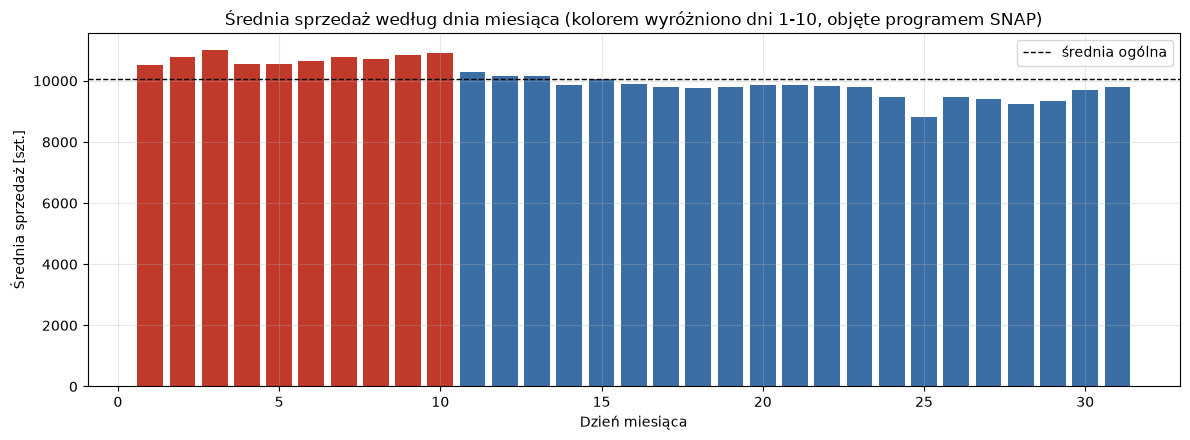

In [147]:
# Efekt programu SNAP
z_snap = s[snap == 1]
bez_snap = s[snap == 0]
t_stat, p_val = stats.ttest_ind(z_snap, bez_snap, equal_var=False)

print("\n" + "=" * 58)
print("[2] EFEKT PROGRAMU SNAP")
print("=" * 58)
print(f"Dni objęte SNAP:        {len(z_snap):5d}   "
      f"średnia: {z_snap.mean():10,.0f} szt.")
print(f"Dni nieobjęte SNAP:     {len(bez_snap):5d}   "
      f"średnia: {bez_snap.mean():10,.0f} szt.")
print(f"\nRóżnica: {z_snap.mean() - bez_snap.mean():,.0f} szt. "
      f"({(z_snap.mean() / bez_snap.mean() - 1) * 100:+.1f}%)")
print(f"Test t (Welch): t = {t_stat:.2f}, p = {p_val:.2e}")

# sprzedaż według dnia miesiąca — obrazuje mechanizm SNAP
dzien_m = s.groupby(s.index.day).mean()
fig, ax = plt.subplots(figsize=(12, 4.5))
kolory = ["#c0392b" if d <= 10 else "#3b6ea5" for d in dzien_m.index]
ax.bar(dzien_m.index, dzien_m.values, color=kolory)
ax.axhline(s.mean(), color="black", linestyle="--", linewidth=1,
           label="średnia ogólna")
ax.set_xlabel("Dzień miesiąca")
ax.set_ylabel("Średnia sprzedaż [szt.]")
ax.set_title("Średnia sprzedaż według dnia miesiąca "
             "(kolorem wyróżniono dni 1-10, objęte programem SNAP)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rys_2_4_snap.png", dpi=200)
plt.show()

In [148]:
# Kontrola: czy amplituda wahań rośnie wraz z poziomem szeregu
roczne_amp = pd.DataFrame({
    "poziom": s.groupby(s.index.year).mean(),
    "odch_std": s.groupby(s.index.year).std(),
})
roczne_amp["wsp_zmiennosci"] = (
    roczne_amp["odch_std"] / roczne_amp["poziom"] * 100)
print("\n" + "=" * 58)
print("[5] ZWIĄZEK ZMIENNOŚCI Z POZIOMEM SZEREGU")
print("=" * 58)
print(roczne_amp.round(1).to_string())
print(f"\nKorelacja poziom - odch. std.: "
      f"{roczne_amp['poziom'].corr(roczne_amp['odch_std']):.3f}")


[5] ZWIĄZEK ZMIENNOŚCI Z POZIOMEM SZEREGU
       poziom  odch_std  wsp_zmiennosci
date                                   
2011   8042.1    1661.0            20.7
2012  10227.5    1938.3            19.0
2013  10454.1    1969.3            18.8
2014  10517.4    1893.7            18.0
2015  10361.6    1975.2            19.1
2016  11509.3    2060.8            17.9

Korelacja poziom - odch. std.: 0.967


In [149]:
y = foods_CA_daily["sales"]
X = foods_CA_daily[["snap"]].astype(float)

h = 28
y_train, y_test = y[:-h], y[-h:]
X_train, X_test = X[:-h], X[-h:]

print(f"Próba ucząca:  {len(y_train):5d} obs.  "
      f"({y_train.index.min().date()} – {y_train.index.max().date()})")
print(f"Próba testowa: {len(y_test):5d} obs.  "
      f"({y_test.index.min().date()} – {y_test.index.max().date()})")

Próba ucząca:   1913 obs.  (2011-01-29 – 2016-04-24)
Próba testowa:    28 obs.  (2016-04-25 – 2016-05-22)


# Badanie stacjonarności

W teście ADF hipoteza zerowa zakłada występowanie pierwiastka jednostkowego
(niestacjonarność), natomiast w teście KPSS — stacjonarność szeregu. Łączne
zastosowanie obu testów pozwala odróżnić przypadki jednoznaczne od
niekonkluzywnych.

In [150]:
def testy_stacjonarnosci(szereg, nazwa):
    szereg = pd.Series(szereg).dropna()
    adf_stat, adf_p = adfuller(szereg, autolag="AIC")[:2]
    kpss_stat, kpss_p = kpss(szereg, regression="c", nlags="auto")[:2]
    return {
        "szereg": nazwa,
        "ADF stat.": round(adf_stat, 4),
        "ADF p": round(adf_p, 4),
        "ADF wniosek": "stacjonarny" if adf_p < 0.05 else "niestacjonarny",
        "KPSS stat.": round(kpss_stat, 4),
        "KPSS p": round(kpss_p, 4),
        "KPSS wniosek": "niestacjonarny" if kpss_p < 0.05 else "stacjonarny",
    }

wyniki_stac = pd.DataFrame([
    testy_stacjonarnosci(y_train, "poziomy"),
    testy_stacjonarnosci(y_train.diff(), "różnicowanie zwykłe (d=1)"),
    testy_stacjonarnosci(y_train.diff(7), "różnicowanie sezonowe (D=1, m=7)"),
    testy_stacjonarnosci(y_train.diff(7).diff(), "różnicowanie zwykłe i sezonowe"),
])
wyniki_stac

,szereg,ADF stat.,ADF p,ADF wniosek,KPSS stat.,KPSS p,KPSS wniosek
0,poziomy,-2.1548,0.223,niestacjonarny,4.0277,0.01,niestacjonarny
1,różnicowanie zwykłe (d=1),-21.2787,0.000,stacjonarny,0.0344,0.10,stacjonarny
2,"różnicowanie sezonowe (D=1, m=7)",-22.0929,0.000,stacjonarny,0.0112,0.10,stacjonarny
3,różnicowanie zwykłe i sezonowe,-21.0545,0.000,stacjonarny,0.0062,0.10,stacjonarny


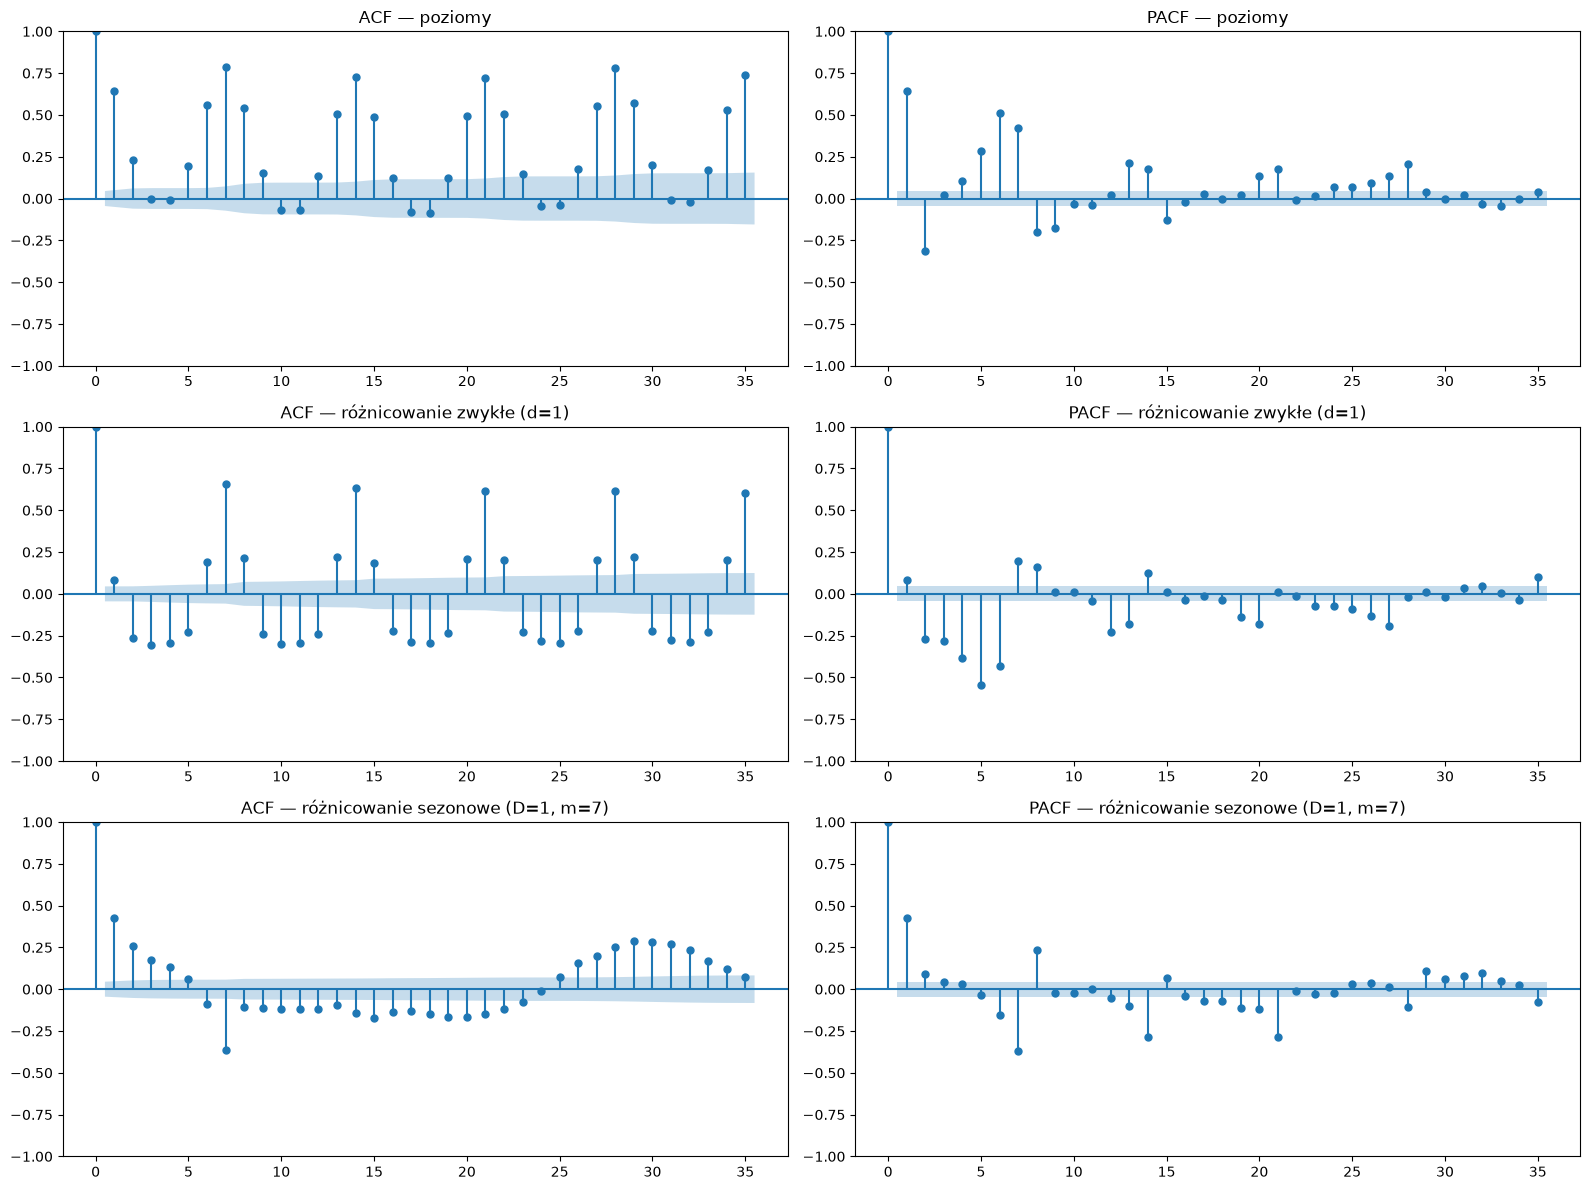

In [151]:
# Korelogramy dla szeregu w poziomach oraz po różnicowaniu
warianty = [
    (y_train, "poziomy"),
    (y_train.diff().dropna(), "różnicowanie zwykłe (d=1)"),
    (y_train.diff(7).dropna(), "różnicowanie sezonowe (D=1, m=7)"),
]

fig, axes = plt.subplots(len(warianty), 2, figsize=(16, 4 * len(warianty)))
for i, (szereg, nazwa) in enumerate(warianty):
    plot_acf(szereg, lags=35, ax=axes[i, 0])
    plot_pacf(szereg, lags=35, ax=axes[i, 1], method="ywm")
    axes[i, 0].set_title(f"ACF — {nazwa}")
    axes[i, 1].set_title(f"PACF — {nazwa}")
plt.tight_layout()
plt.savefig("rys_2_5_korelogramy.png", dpi=200)
plt.show()

# Wnioski dotyczące korelogramów

Funkcja autokorelacji szeregu w poziomach wygasa powoli i wykazuje wyraźne
maksima w opóźnieniach będących wielokrotnością siedmiu, co potwierdza obecność
sezonowości tygodniowej i uzasadnia różnicowanie sezonowe (D = 1, m = 7).
Jako specyfikację dobraną ręcznie przyjęto model SARIMA(1,1,1)(1,1,1)[7].

# Automatyczny dobór parametrów

In [152]:
food_model = pm.auto_arima(
    y_train, seasonal=True, D=1, m=7,
    stepwise=True, suppress_warnings=True, trace=True
)

print("\nRząd (p,d,q):        ", food_model.order)
print("Rząd sezonowy:       ", food_model.seasonal_order)
print("Wyraz wolny:         ", getattr(food_model, "with_intercept", None))
print("AIC wg auto_arima:   ", round(food_model.aic(), 3))

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[7] intercept   : AIC=inf, Time=3.01 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=32991.456, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=32229.482, Time=0.70 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=31938.777, Time=1.00 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=32989.590, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=32699.582, Time=0.09 sec
 ARIMA(0,0,1)(1,1,1)[7] intercept   : AIC=31923.303, Time=1.47 sec
 ARIMA(0,0,1)(1,1,0)[7] intercept   : AIC=32382.274, Time=0.60 sec
 ARIMA(0,0,1)(2,1,1)[7] intercept   : AIC=31911.270, Time=3.11 sec
 ARIMA(0,0,1)(2,1,0)[7] intercept   : AIC=32194.472, Time=1.26 sec
 ARIMA(0,0,1)(2,1,2)[7] intercept   : AIC=inf, Time=4.09 sec
 ARIMA(0,0,1)(1,1,2)[7] intercept   : AIC=31945.313, Time=3.87 sec
 ARIMA(0,0,0)(2,1,1)[7] intercept   : AIC=32248.977, Time=2.63 sec
 ARIMA(1,0,1)(2,1,1)[7] intercept   : AIC=31698.108, Time=3.70 sec
 ARIMA(1,0,1)(1,1,1)[7] interce

In [153]:
food_model_with_params = pm.auto_arima(
    y_train, X=X_train, seasonal=True, D=1, m=7,
    stepwise=True, suppress_warnings=True, trace=True
)

print("\nRząd (p,d,q):        ", food_model_with_params.order)
print("Rząd sezonowy:       ", food_model_with_params.seasonal_order)
print("Wyraz wolny:         ",
      getattr(food_model_with_params, "with_intercept", None))
print("AIC wg auto_arima:   ", round(food_model_with_params.aic(), 3))

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[7] intercept   : AIC=inf, Time=3.52 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=32440.404, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=31947.111, Time=0.88 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=31624.611, Time=1.19 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=32438.674, Time=0.25 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=32313.492, Time=0.11 sec
 ARIMA(0,0,1)(1,1,1)[7] intercept   : AIC=31611.691, Time=1.53 sec
 ARIMA(0,0,1)(1,1,0)[7] intercept   : AIC=31970.988, Time=0.76 sec
 ARIMA(0,0,1)(2,1,1)[7] intercept   : AIC=31610.994, Time=3.50 sec
 ARIMA(0,0,1)(2,1,0)[7] intercept   : AIC=31802.056, Time=1.48 sec
 ARIMA(0,0,1)(2,1,2)[7] intercept   : AIC=31616.899, Time=4.54 sec
 ARIMA(0,0,1)(1,1,2)[7] intercept   : AIC=31612.249, Time=4.26 sec
 ARIMA(0,0,0)(2,1,1)[7] intercept   : AIC=31802.282, Time=2.61 sec
 ARIMA(1,0,1)(2,1,1)[7] intercept   : AIC=inf, Time=4.20 sec
 ARIMA(0,0,2)(2,1,1)[7] interce

# Budowa modeli

Estymowanych jest pięć specyfikacji. Modele 2 i 4 mają identyczne rzędy i różnią
się wyłącznie obecnością zmiennej egzogenicznej; analogicznie modele 5 i 3.
Dopiero takie zestawienie *ceteris paribus* pozwala przypisać różnicę w jakości
prognoz wpływowi programu SNAP, a nie odmiennej strukturze modelu.

In [154]:
def dopasuj(y, order, seasonal_order, with_intercept, exog=None):
    """Estymacja SARIMAX z wyrazem wolnym zgodnym z wyborem auto_arima."""
    trend = "c" if with_intercept else None
    return SARIMAX(
        y, exog=exog, order=order, seasonal_order=seasonal_order, trend=trend,
        enforce_stationarity=True, enforce_invertibility=False,
    ).fit(disp=False)


order_auto = food_model.order
seas_auto = food_model.seasonal_order
int_auto = bool(getattr(food_model, "with_intercept", False))

order_snap = food_model_with_params.order
seas_snap = food_model_with_params.seasonal_order
int_snap = bool(getattr(food_model_with_params, "with_intercept", False))

print(f"Model 2/4: {order_auto}{seas_auto}, wyraz wolny: {int_auto}")
print(f"Model 3/5: {order_snap}{seas_snap}, wyraz wolny: {int_snap}")

Model 2/4: (1, 0, 1)(1, 1, 1, 7), wyraz wolny: True
Model 3/5: (0, 0, 5)(1, 1, 1, 7), wyraz wolny: True


In [155]:
# Model 1: specyfikacja dobrana ręcznie na podstawie korelogramów
sarimax_hand = dopasuj(y_train, (1, 1, 1), (1, 1, 1, 7), with_intercept=False)

# Model 2: auto_arima, bez zmiennej egzogenicznej
sarimax_auto = dopasuj(y_train, order_auto, seas_auto, int_auto)

# Model 3: auto_arima dobrany przy udziale SNAP, ze zmienną egzogeniczną
sarimax_snap = dopasuj(y_train, order_snap, seas_snap, int_snap, exog=X_train)

# Model 4: rzędy modelu 2, ale ze zmienną egzogeniczną
sarimax_auto_snap = dopasuj(y_train, order_auto, seas_auto, int_auto, exog=X_train)

# Model 5: rzędy modelu 3, ale bez zmiennej egzogenicznej
sarimax_snap_bez = dopasuj(y_train, order_snap, seas_snap, int_snap)

print("Kontrola zgodności reestymacji z wynikiem auto_arima:")
print(f"  model 2: {sarimax_auto.aic:12.3f} vs {food_model.aic():12.3f}"
      f"    różnica: {abs(sarimax_auto.aic - food_model.aic()):8.3f}")
print(f"  model 3: {sarimax_snap.aic:12.3f} vs {food_model_with_params.aic():12.3f}"
      f"    różnica: {abs(sarimax_snap.aic - food_model_with_params.aic()):8.3f}")

Kontrola zgodności reestymacji z wynikiem auto_arima:
  model 2:    31697.548 vs    31694.882    różnica:    2.666
  model 3:    31539.646 vs    31539.650    różnica:    0.004


In [156]:
modele = {
    "Model 1 (ręczny)": sarimax_hand,
    "Model 2 (auto)": sarimax_auto,
    "Model 3 (auto + SNAP)": sarimax_snap,
    "Model 4 (rzędy m.2 + SNAP)": sarimax_auto_snap,
    "Model 5 (rzędy m.3 bez SNAP)": sarimax_snap_bez,
}

In [157]:
# Kontrola zgodności reestymacji z wyborem auto_arima
print("\n" + "=" * 70)
print("KONTROLA ZGODNOŚCI Z auto_arima")
print("=" * 70)
r1 = abs(sarimax_auto.aic - food_model.aic())
r2 = abs(sarimax_snap.aic - food_model_with_params.aic())
print(f"Model 2: {sarimax_auto.aic:12,.3f} vs {food_model.aic():12,.3f}"
      f"   różnica: {r1:.3f}")
print(f"Model 3: {sarimax_snap.aic:12,.3f} vs "
      f"{food_model_with_params.aic():12,.3f}   różnica: {r2:.3f}")


KONTROLA ZGODNOŚCI Z auto_arima
Model 2:   31,697.548 vs   31,694.882   różnica: 2.666
Model 3:   31,539.646 vs   31,539.650   różnica: 0.004


In [158]:
# Zbiorcza tabela oszacowań: ocena, błąd standardowy, p-value
print("=" * 70)
print("OSZACOWANIA PARAMETRÓW")
print("=" * 70)
for nazwa, m in modele.items():
    tab = pd.DataFrame({
        "ocena": m.params,
        "bl_std": m.bse,
        "z": m.tvalues,
        "p": m.pvalues,
    })
    print(f"\n--- {nazwa}   AIC = {m.aic:,.1f}")
    print(tab.round(4).to_string())

OSZACOWANIA PARAMETRÓW

--- Model 1 (ręczny)   AIC = 31,658.9
               ocena      bl_std         z    p
ar.L1         0.4268      0.0129   33.0534  0.0
ma.L1        -1.0507      0.0096 -109.2418  0.0
ar.S.L7       0.1376      0.0210    6.5636  0.0
ma.S.L7      -1.0206      0.0066 -154.6441  0.0
sigma2   821753.9154  16970.7259   48.4218  0.0

--- Model 2 (auto)   AIC = 31,697.5
                 ocena     bl_std        z       p
intercept       3.5301     1.5030   2.3488  0.0188
ar.L1           0.7806     0.0225  34.6842  0.0000
ma.L1          -0.3841     0.0255 -15.0583  0.0000
ar.S.L7         0.1068     0.0230   4.6356  0.0000
ma.S.L7        -0.9119     0.0095 -95.5792  0.0000
sigma2     967065.2719  9962.3237  97.0723  0.0000

--- Model 3 (auto + SNAP)   AIC = 31,539.6
                 ocena     bl_std        z       p
intercept      14.8530     7.1812   2.0683  0.0386
snap         1019.4726    69.8190  14.6017  0.0000
ma.L1           0.3282     0.0121  27.1233  0.0000
ma.L2   

In [159]:
# Efekt SNAP w odniesieniu do poziomu szeregu
print("\n" + "=" * 70)
print("EFEKT SNAP")
print("=" * 70)
for nazwa in ["Model 3 (auto + SNAP)", "Model 4 (rzędy m.2 + SNAP)"]:
    m = modele[nazwa]
    if "snap" in m.params.index:
        b = m.params["snap"]
        se = m.bse["snap"]
        print(f"{nazwa}")
        print(f"    ocena: {b:10,.1f}   bł. std.: {se:8,.1f}   "
              f"z = {b/se:6.2f}   p = {m.pvalues['snap']:.2e}")
        print(f"    udział w średniej sprzedaży: "
              f"{b / y_train.mean() * 100:.1f}%")


EFEKT SNAP
Model 3 (auto + SNAP)
    ocena:    1,019.5   bł. std.:     69.8   z =  14.60   p = 2.74e-48
    udział w średniej sprzedaży: 10.2%
Model 4 (rzędy m.2 + SNAP)
    ocena:    1,021.5   bł. std.:     61.3   z =  16.65   p = 2.85e-62
    udział w średniej sprzedaży: 10.2%


In [160]:
# Warunki stacjonarności i odwracalności
print("\n" + "=" * 70)
print("PIERWIASTKI WIELOMIANÓW CHARAKTERYSTYCZNYCH")
print("      (moduł > 1 oznacza spełnienie warunku)")
print("=" * 70)
for nazwa, m in modele.items():
    ar = np.abs(m.arroots) if len(m.arroots) else np.array([])
    ma = np.abs(m.maroots) if len(m.maroots) else np.array([])
    ok_ar = "spełniony" if (ar > 1).all() or len(ar) == 0 else "NARUSZONY"
    ok_ma = "spełniony" if (ma > 1).all() or len(ma) == 0 else "NARUSZONY"
    print(f"\n--- {nazwa}")
    if len(ar):
        print(f"    AR  min |pierwiastek| = {ar.min():7.3f}   -> {ok_ar}")
    else:
        print(f"    AR  brak parametrów")
    if len(ma):
        print(f"    MA  min |pierwiastek| = {ma.min():7.3f}   -> {ok_ma}")
    else:
        print(f"    MA  brak parametrów")


PIERWIASTKI WIELOMIANÓW CHARAKTERYSTYCZNYCH
      (moduł > 1 oznacza spełnienie warunku)

--- Model 1 (ręczny)
    AR  min |pierwiastek| =   1.328   -> spełniony
    MA  min |pierwiastek| =   0.952   -> NARUSZONY

--- Model 2 (auto)
    AR  min |pierwiastek| =   1.281   -> spełniony
    MA  min |pierwiastek| =   1.013   -> spełniony

--- Model 3 (auto + SNAP)
    AR  min |pierwiastek| =   1.319   -> spełniony
    MA  min |pierwiastek| =   1.024   -> spełniony

--- Model 4 (rzędy m.2 + SNAP)
    AR  min |pierwiastek| =   1.000   -> spełniony
    MA  min |pierwiastek| =   1.002   -> spełniony

--- Model 5 (rzędy m.3 bez SNAP)
    AR  min |pierwiastek| =   1.312   -> spełniony
    MA  min |pierwiastek| =   1.017   -> spełniony


In [161]:
print(sarimax_hand.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1913
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -15824.452
Date:                           Tue, 01 Sep 2026   AIC                          31658.905
Time:                                   23:42:10   BIC                          31686.666
Sample:                               01-29-2011   HQIC                         31669.123
                                    - 04-24-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4268      0.013     33.053      0.000       0.401       0.452
ma.L1         -1.0507      0.010   -109.242

In [162]:
print(sarimax_auto.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1913
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -15842.774
Date:                           Tue, 01 Sep 2026   AIC                          31697.548
Time:                                   23:42:10   BIC                          31730.864
Sample:                               01-29-2011   HQIC                         31709.811
                                    - 04-24-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.5301      1.503      2.349      0.019       0.584       6.476
ar.L1          0.7806      0.023     34.684

In [163]:
print(sarimax_snap.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               sales   No. Observations:                 1913
Model:             SARIMAX(0, 0, 5)x(1, 1, [1], 7)   Log Likelihood              -15759.823
Date:                             Tue, 01 Sep 2026   AIC                          31539.646
Time:                                     23:42:10   BIC                          31595.174
Sample:                                 01-29-2011   HQIC                         31560.084
                                      - 04-24-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     14.8530      7.181      2.068      0.039       0.778      28.928
snap        1019.4726     6

# Prognozy i ocena jakości

In [164]:
n_periods = h

# Prognoza naiwna sezonowa (benchmark)
last_week = y_train.iloc[-7:].values
pred_naive = pd.Series(
    np.tile(last_week, int(np.ceil(n_periods / 7)))[:n_periods],
    index=y_test.index
)

def prognoza(model, exog=None):
    fc = model.get_forecast(steps=n_periods, exog=exog)
    return fc.predicted_mean, fc.conf_int()

pred_hand, ci_hand = prognoza(sarimax_hand)
pred_auto, ci_auto = prognoza(sarimax_auto)
pred_snap, ci_snap = prognoza(sarimax_snap, exog=X_test)
pred_auto_snap, ci_auto_snap = prognoza(sarimax_auto_snap, exog=X_test)
pred_snap_bez, ci_snap_bez = prognoza(sarimax_snap_bez)

In [165]:
def mase(y_true, y_pred, y_hist, m=7):
    """Mean Absolute Scaled Error skalowany naiwną prognozą sezonową."""
    y_hist = np.asarray(y_hist, dtype=float)
    skala = np.mean(np.abs(y_hist[m:] - y_hist[:-m]))
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / skala


def ocena(y_pred, etykieta, model=None):
    return {
        "model": etykieta,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MASE": mase(y_test, y_pred, y_train),
        "AIC": np.nan if model is None else model.aic,
        "SNAP": "" if model is None else
                ("tak" if "snap" in model.model.param_names else "nie"),
    }


results = pd.DataFrame([
    ocena(pred_naive, "0. Naiwna sezonowa"),
    ocena(pred_hand, "1. Ręczny (1,1,1)(1,1,1,7)", sarimax_hand),
    ocena(pred_auto, "2. auto_arima", sarimax_auto),
    ocena(pred_snap, "3. auto_arima + SNAP", sarimax_snap),
    ocena(pred_auto_snap, "4. Rzędy modelu 2 + SNAP", sarimax_auto_snap),
    ocena(pred_snap_bez, "5. Rzędy modelu 3 bez SNAP", sarimax_snap_bez),
])
results.round(3)

,model,MAE,RMSE,MASE,AIC,SNAP
0,0. Naiwna sezonowa,820.107,940.019,0.825,NaN,
1,"1. Ręczny (1,1,1)(1,1,1,7)",692.071,831.310,0.696,31658.905,nie
2,2. auto_arima,830.869,955.418,0.836,31697.548,nie
3,3. auto_arima + SNAP,670.328,858.202,0.674,31539.646,tak
4,4. Rzędy modelu 2 + SNAP,584.468,786.461,0.588,31535.088,tak
5,5. Rzędy modelu 3 bez SNAP,827.425,953.944,0.832,31732.776,nie


In [166]:
print(f"MAE modelu 4 jako % średniej w okresie testowym: "
      f"{584.468 / y_test.mean() * 100:.1f}%")

MAE modelu 4 jako % średniej w okresie testowym: 4.8%


In [167]:
# Izolacja efektu zmiennej egzogenicznej — porównania ceteris paribus
r = results.set_index("model")

def efekt(bez, z, nazwa):
    return {
        "porównanie": nazwa,
        "MAE bez SNAP": bez["MAE"],
        "MAE ze SNAP": z["MAE"],
        "zmiana MAE [%]": (z["MAE"] - bez["MAE"]) / bez["MAE"] * 100,
        "AIC bez SNAP": bez["AIC"],
        "AIC ze SNAP": z["AIC"],
        "delta AIC": z["AIC"] - bez["AIC"],
    }

efekty = pd.DataFrame([
    efekt(r.loc["2. auto_arima"], r.loc["4. Rzędy modelu 2 + SNAP"],
          f"rzędy {order_auto}{seas_auto}"),
    efekt(r.loc["5. Rzędy modelu 3 bez SNAP"], r.loc["3. auto_arima + SNAP"],
          f"rzędy {order_snap}{seas_snap}"),
])
efekty.round(3)

,porównanie,MAE bez SNAP,MAE ze SNAP,zmiana MAE [%],AIC bez SNAP,AIC ze SNAP,delta AIC
0,"rzędy (1, 0, 1)(1, 1, 1, 7)",830.869,584.468,-29.656,31697.548,31535.088,-162.46
1,"rzędy (0, 0, 5)(1, 1, 1, 7)",827.425,670.328,-18.986,31732.776,31539.646,-193.13


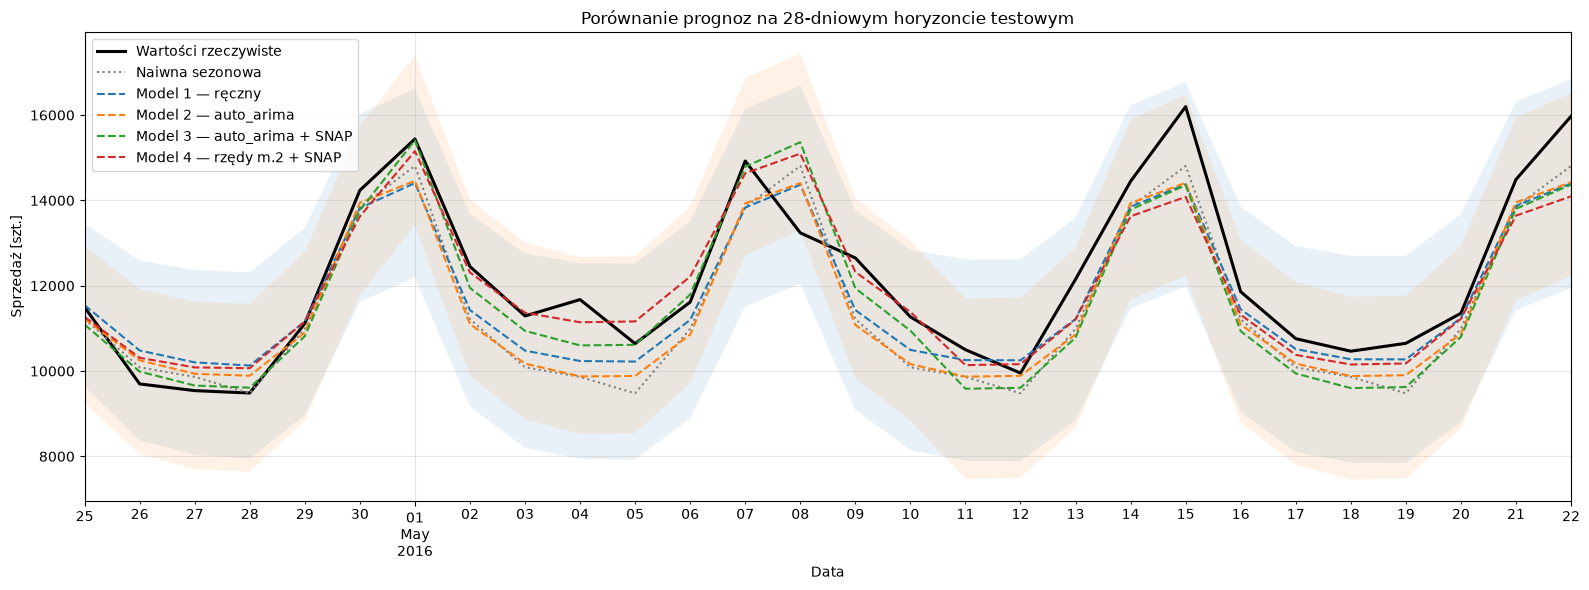

In [168]:
fig, ax = plt.subplots(figsize=(16, 6))
y_test.plot(ax=ax, label="Wartości rzeczywiste", color="black", linewidth=2.2)
pred_naive.plot(ax=ax, label="Naiwna sezonowa", color="grey", linestyle=":")
pred_hand.plot(ax=ax, label="Model 1 — ręczny", linestyle="--")
pred_auto.plot(ax=ax, label="Model 2 — auto_arima", linestyle="--")
pred_snap.plot(ax=ax, label="Model 3 — auto_arima + SNAP", linestyle="--")
pred_auto_snap.plot(ax=ax, label="Model 4 — rzędy m.2 + SNAP", linestyle="--")
ax.fill_between(ci_hand.index, ci_hand.iloc[:, 0], ci_hand.iloc[:, 1], alpha=0.10)
ax.fill_between(ci_snap.index, ci_snap.iloc[:, 0], ci_snap.iloc[:, 1], alpha=0.10)
ax.set_title("Porównanie prognoz na 28-dniowym horyzoncie testowym")
ax.set_xlabel("Data")
ax.set_ylabel("Sprzedaż [szt.]")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rys_3_prognozy.png", dpi=200)
plt.show()

# Diagnostyka reszt

Weryfikacja braku autokorelacji reszt (test Ljunga–Boxa) oraz ocena ich rozkładu.
Ostatnia komórka dokumentuje wpływ zer strukturalnych na miary rozkładu — jest
to materiał dowodowy dla komentarza zamieszczonego w tekście pracy.

In [169]:
# Diagnostyka reszt — poprawne stopnie swobody testu Ljunga-Boxa.
# UWAGA: m.model.k_seasonal_ar zwraca P*s (a nie P), dlatego rzędy
# odczytujemy wprost ze specyfikacji modelu.
specyfikacje = {
    "1. Ręczny":              (sarimax_hand,      (1, 1, 1), (1, 1, 1, 7)),
    "2. auto_arima":          (sarimax_auto,      order_auto, seas_auto),
    "3. auto_arima + SNAP":   (sarimax_snap,      order_snap, seas_snap),
    "4. Rzędy m. 2 + SNAP":   (sarimax_auto_snap, order_auto, seas_auto),
    "5. Rzędy m. 3 bez SNAP": (sarimax_snap_bez,  order_snap, seas_snap),
}

LAGS = [14, 21, 28]      # muszą przewyższać df_model
wiersze = []

for nazwa, (m, order, seas) in specyfikacje.items():
    p, d, q = order
    P, D, Q, s = seas
    df_model = p + q + P + Q

    r = pd.Series(m.resid, index=y_train.index)
    r = r.iloc[max(m.loglikelihood_burn, d + D * s + p + P * s):]

    maska = ~((r.index.month == 12) & (r.index.day.isin([25, 26])))
    r_bez = r[maska]

    lb  = acorr_ljungbox(r,     lags=LAGS, model_df=df_model, return_df=True)
    lbb = acorr_ljungbox(r_bez, lags=LAGS, model_df=df_model, return_df=True)

    wiersze.append({
        "model": nazwa,
        "df": df_model,
        "LB(14)": lb.loc[14, "lb_pvalue"],
        "LB(21)": lb.loc[21, "lb_pvalue"],
        "LB(28)": lb.loc[28, "lb_pvalue"],
        "LB(21) bez świąt": lbb.loc[21, "lb_pvalue"],
        "max |r_k|": abs(sm.tsa.acf(r, nlags=28)[1:]).max(),
        "max |r_k| bez świąt": abs(sm.tsa.acf(r_bez, nlags=28)[1:]).max(),
        "skośność": r.skew(),
        "kurtoza": r.kurtosis() + 3,
    })

diagnostyka = pd.DataFrame(wiersze).round(4)
print(f"Próg istotności pojedynczej autokorelacji: "
      f"±{1.96 / len(y_train) ** 0.5:.4f}")
diagnostyka

Próg istotności pojedynczej autokorelacji: ±0.0448


,model,df,LB(14),LB(21),LB(28),LB(21) bez świąt,max |r_k|,max |r_k| bez świąt,skośność,kurtoza
0,1. Ręczny,4,0.0000,0.0000,0.0,0.0,0.1230,0.1555,-2.0642,26.7353
1,2. auto_arima,4,0.0003,0.0036,0.0,0.0,0.0896,0.1265,-2.3524,28.7563
2,3. auto_arima + SNAP,7,0.0000,0.0000,0.0,0.0,0.1157,0.1532,-2.4826,30.2658
3,4. Rzędy m. 2 + SNAP,4,0.0000,0.0000,0.0,0.0,0.1913,0.2655,-2.6465,32.7930
4,5. Rzędy m. 3 bez SNAP,7,0.0000,0.0000,0.0,0.0,0.1129,0.1735,-2.1772,26.8815


In [170]:
for nazwa, (m, order, seas) in specyfikacje.items():
    r = pd.Series(m.resid, index=y_train.index).iloc[16:]
    a = sm.tsa.acf(r, nlags=30)[1:]
    k = abs(a).argmax() + 1
    print(f"{nazwa:26s} max |r_k| = {abs(a).max():.4f} przy k = {k}")

1. Ręczny                  max |r_k| = 0.1252 przy k = 29
2. auto_arima              max |r_k| = 0.1239 przy k = 29
3. auto_arima + SNAP       max |r_k| = 0.1133 przy k = 8
4. Rzędy m. 2 + SNAP       max |r_k| = 0.1924 przy k = 1
5. Rzędy m. 3 bez SNAP     max |r_k| = 0.1363 przy k = 29


In [171]:
# Wpływ zer strukturalnych na rozkład reszt modelu ręcznego
reszty = pd.Series(sarimax_hand.resid, index=y_train.index)
reszty = reszty.iloc[max(sarimax_hand.loglikelihood_burn, 8):]
sigma = reszty.std()

swieta_train = [d for d in swieta if d in reszty.index]
print("Reszty w dniach zamknięć świątecznych:\n")
print(f"{'data':14s}{'reszta':>14s}{'w jedn. sigma':>16s}")
for d in swieta_train:
    print(f"{str(d.date()):14s}{reszty.loc[d]:14,.0f}{reszty.loc[d] / sigma:16.1f}")

reszty_bez = reszty.drop(index=swieta_train)
print(f"\n{'':22s}{'skośność':>12s}{'kurtoza':>12s}")
print(f"{'wszystkie reszty':22s}{reszty.skew():12.2f}{reszty.kurtosis() + 3:12.2f}")
print(f"{'bez dni świątecznych':22s}"
      f"{reszty_bez.skew():12.2f}{reszty_bez.kurtosis() + 3:12.2f}")

Reszty w dniach zamknięć świątecznych:

data                  reszta   w jedn. sigma
2011-12-25           -10,787           -11.0
2012-12-25            -8,801            -9.0
2013-12-25            -8,769            -8.9
2014-12-25            -8,294            -8.5
2015-12-25           -10,006           -10.2

                          skośność     kurtoza
wszystkie reszty             -2.04       26.36
bez dni świątecznych          0.35        6.03


In [172]:
reszty = pd.Series(sarimax_hand.resid, index=y_train.index)
reszty = reszty.iloc[max(sarimax_hand.loglikelihood_burn, 8):]
print((reszty / reszty.std()).abs().nlargest(10).to_string())

date
2011-12-25    11.001862
2015-12-25    10.205235
2012-12-25     8.976262
2013-12-25     8.944093
2014-12-25     8.459875
2011-12-26     4.832509
2013-12-26     4.725353
2014-12-11     3.933498
2014-07-03     3.812076
2015-07-04     3.799865
